In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import random
%matplotlib inline
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import sys
import os
sys.path.append(os.path.abspath('..'))  # adds project root to path

from src.data_cleaning import clean_data
from src.product_categorisation import categorise_products

# Set plotting style for a clean, professional look
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load the raw data and apply data cleaning steps

raw_df = pd.read_csv('../data/raw/online_retail_II.csv')
cleaned_df = clean_data(raw_df)
df = categorise_products(cleaned_df)

In [2]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,date,year,month,week,Revenue,category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,2009-12-01,2009,12,49,83.40,Seasonal & Festive
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009-12-01,2009,12,49,81.00,Other
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009-12-01,2009,12,49,81.00,Other
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,2009-12-01,2009,12,49,100.80,Home Decor & Accessories
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,2009-12-01,2009,12,49,30.00,Home Decor & Accessories


## Part 1: Category Distribution (Full Dataset)
We visualise the SKU counts, revenue share and transaction counts per category to visualise the distribution before applying any transaction-level filtering.

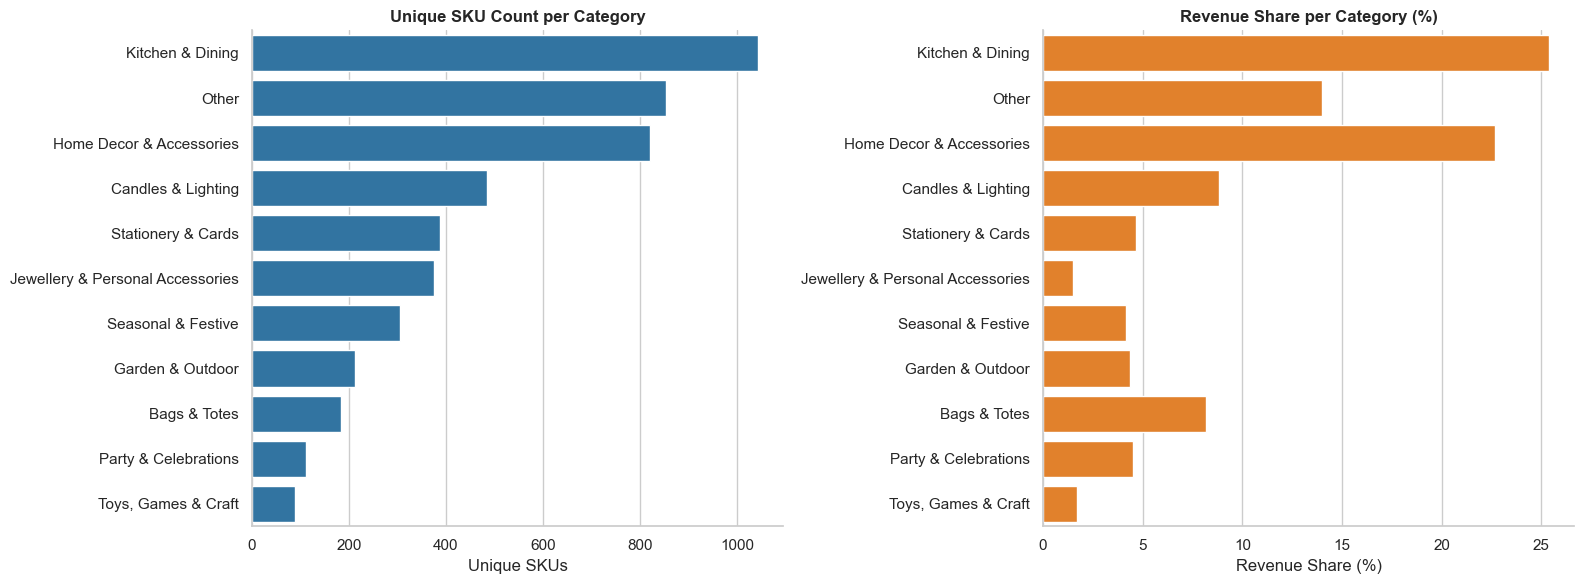

In [3]:
# Calculate unique SKUs and Revenue per category
df['Revenue'] = df['Quantity'] * df['Price']

cat_sku_counts = df.groupby('category')['StockCode'].nunique().sort_values(ascending=False)
cat_revenue = df.groupby('category')['Revenue'].sum().reindex(cat_sku_counts.index)
cat_revenue_pct = (cat_revenue / cat_revenue.sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Unique SKU Count
sns.barplot(x=cat_sku_counts.values, y=cat_sku_counts.index, ax=axes[0], color="#1f77b4")
axes[0].set_title("Unique SKU Count per Category", fontweight="bold")
axes[0].set_xlabel("Unique SKUs")
axes[0].set_ylabel("")

# Right panel: Revenue Share
sns.barplot(x=cat_revenue_pct.values, y=cat_revenue_pct.index, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Revenue Share per Category (%)", fontweight="bold")
axes[1].set_xlabel("Revenue Share (%)")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/05_category_distribution.png');

The following 3 categories lead in SKU counts and revenue share:
<ol>
<li>Kitchen & Dining
<li>Home Decor & Accessories
<li>Other</ol>|

In [4]:
category_summary = (
    df.groupby("category")
    .agg(
        unique_skus=("StockCode", "nunique"),
        transaction_rows=("StockCode", "count"),
    )
    .reset_index()
)

category_summary["pct_of_skus"] = (
    category_summary["unique_skus"] / category_summary["unique_skus"].sum() * 100
)
category_summary["pct_of_transactions"] = (
    category_summary["transaction_rows"] / category_summary["transaction_rows"].sum() * 100
)

category_summary = category_summary.sort_values("unique_skus", ascending=False).reset_index(drop=True)

print(f"Total unique SKUs: {category_summary['unique_skus'].sum():,}")
print(f"Total transactions: {category_summary['transaction_rows'].sum():,}")
category_summary

Total unique SKUs: 4,863
Total transactions: 954,730


,category,unique_skus,transaction_rows,pct_of_skus,pct_of_transactions
0,Kitchen & Dining,1043,237577,21.45,24.88
1,Other,853,151395,17.54,15.86
2,Home Decor & Accessories,820,190281,16.86,19.93
3,Candles & Lighting,484,69217,9.95,7.25
4,Stationery & Cards,387,71486,7.96,7.49
5,Jewellery & Personal Accessories,375,22643,7.71,2.37
6,Seasonal & Festive,305,47831,6.27,5.01
7,Garden & Outdoor,212,40355,4.36,4.23
8,Bags & Totes,184,70980,3.78,7.43
9,Party & Celebrations,111,32236,2.28,3.38


d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


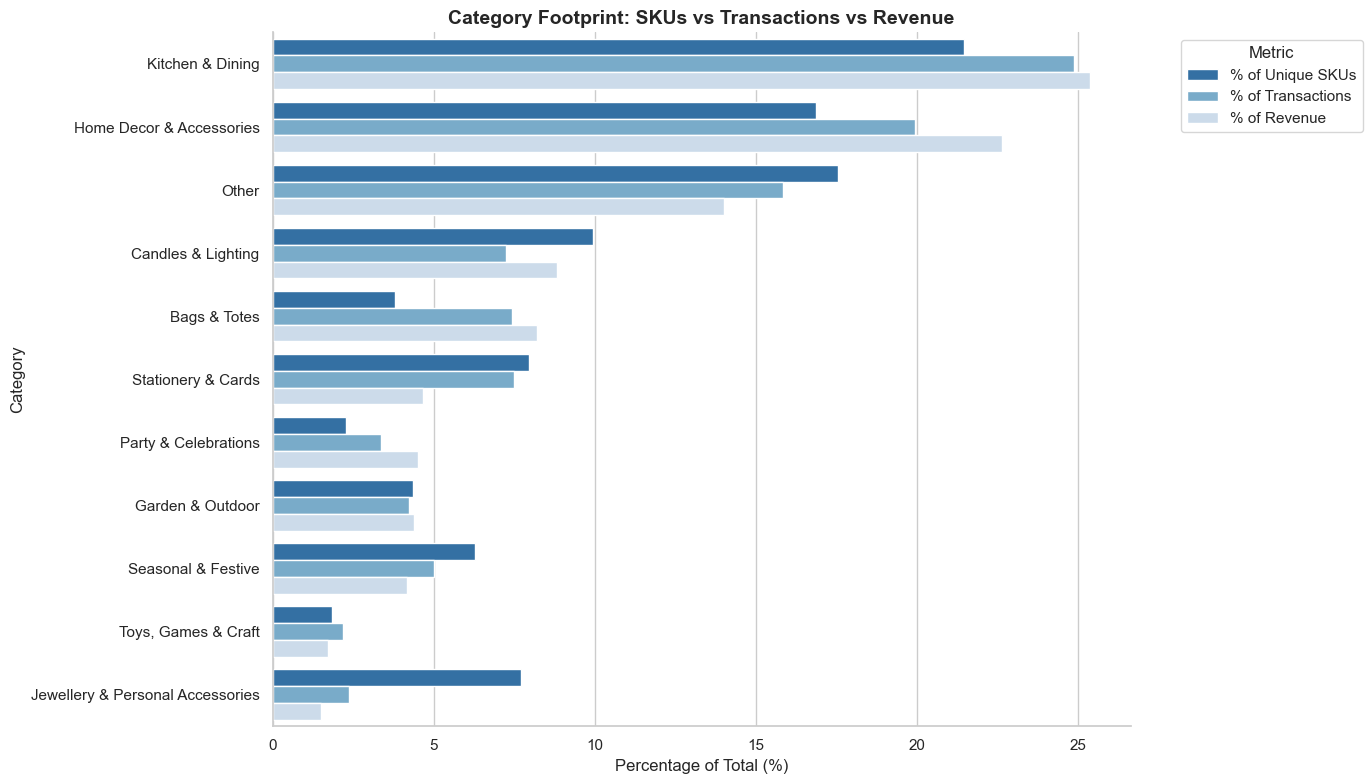

In [5]:
# Map the revenue percentages from Part 1 into our summary table
category_summary['pct_of_revenue'] = category_summary['category'].map(cat_revenue_pct)

# Sort the summary table by Revenue (descending) to establish a clean visual hierarchy
category_summary = category_summary.sort_values('pct_of_revenue', ascending=False)

# Reshape the dataframe from wide to long format so Seaborn can plot grouped bars
plot_df = category_summary[['category', 'pct_of_skus', 'pct_of_transactions', 'pct_of_revenue']].melt(
    id_vars='category', 
    var_name='Metric', 
    value_name='Percentage'
)

# Rename the metrics for a cleaner legend
plot_df['Metric'] = plot_df['Metric'].map({
    'pct_of_skus': '% of Unique SKUs',
    'pct_of_transactions': '% of Transactions',
    'pct_of_revenue': '% of Revenue'
})

# Draw the grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=plot_df, 
    x='Percentage', 
    y='category', 
    hue='Metric', 
    palette='Blues_r', 
    ax=ax
)

ax.set_title("Category Footprint: SKUs vs Transactions vs Revenue", fontsize=14, fontweight='bold')
ax.set_xlabel("Percentage of Total (%)", fontsize=12)
ax.set_ylabel("Category")

# Move legend outside the plot area so it doesn't overlap the bars
ax.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/05_category_footprint_comparison.png')
plt.show();

We see that the same 3 categories lead in the number of transactions. We do this to check if number of SKUs, revenue and number of transactions are directly correlated.<br>
Specifically, to check if there could've been a category driving revenue based on higher prices but lower transactions.

## Part 2: Price Distribution per Category
To understand whether our categories are internally coherent, we examine the spread of unit prices within each segment. This visually highlights why a single, unsegmented elasticity model would fail: different product categories operate on fundamentally different price architectures.

d:\Get a job\Projects\Online Retail UCl\.venv\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


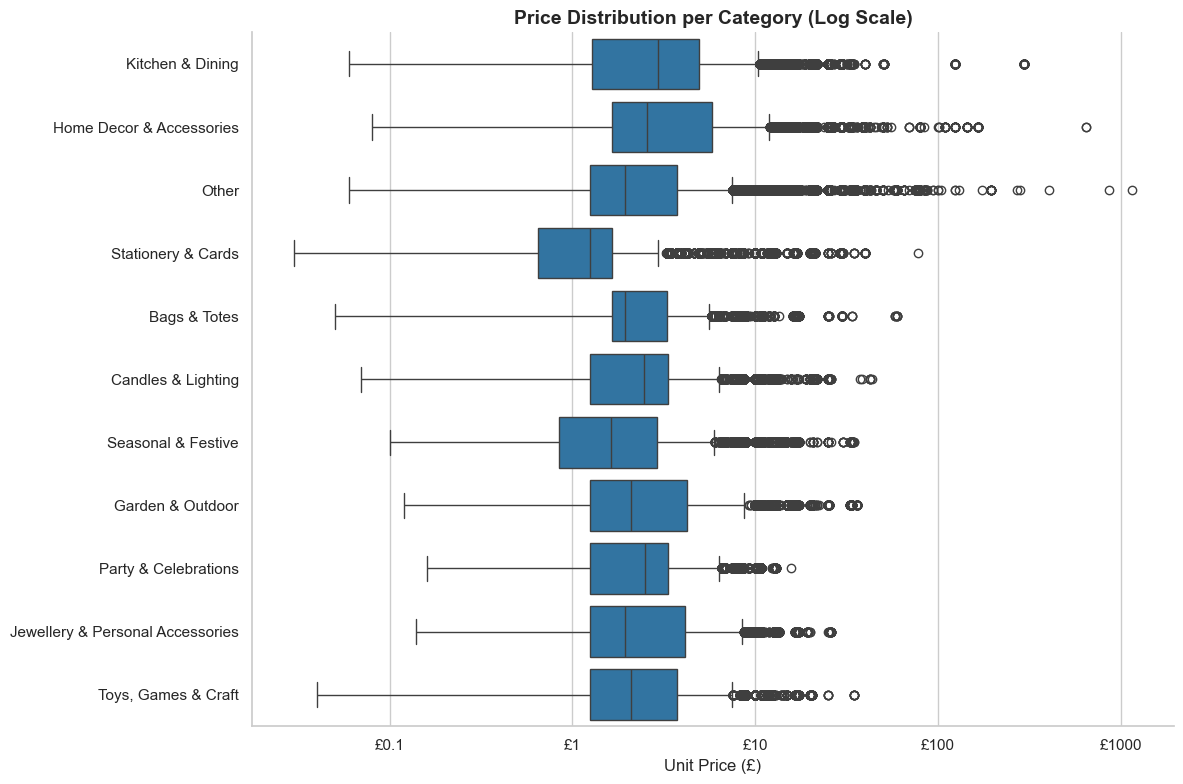

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create the boxplot
# Note: Ensure your column is named 'UnitPrice' or 'Price' according to your previous cleaning step. 
# Using 'Price' here based on standard UK Retail II Kaggle cleanings.
sns.boxplot(
    data=df, 
    x="Price", 
    y="category", 
    color="#1f77b4", 
    ax=ax,
    order=df['category'].value_counts().index # Order by size for readability
)

# Apply log scale to handle extreme right-skewness common in retail pricing
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"£{x:g}"))

ax.set_title("Price Distribution per Category (Log Scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("Unit Price (£)", fontsize=12)
ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/06_price_distribution_boxplot.png')
plt.show();

In [7]:
# Calculate Q1, Median, and Q3 per category
price_stats = df.groupby('category')['Price'].agg(
    Q1=lambda x: x.quantile(0.25),
    Median='median',
    Q3=lambda x: x.quantile(0.75)
).reset_index()

# Calculate the Interquartile Range (IQR)
price_stats['IQR'] = price_stats['Q3'] - price_stats['Q1']

# Sort the dataframe to exactly match the top-to-bottom order of the boxplot above
cat_order = df['category'].value_counts().index
price_stats['category'] = pd.Categorical(price_stats['category'], categories=cat_order, ordered=True)
price_stats = price_stats.sort_values('category').reset_index(drop=True)

# Format the output for clean reading
price_stats

,category,Q1,Median,Q3,IQR
0,Kitchen & Dining,1.28,2.95,4.95,3.67
1,Home Decor & Accessories,1.65,2.55,5.79,4.14
2,Other,1.25,1.95,3.75,2.50
3,Stationery & Cards,0.65,1.25,1.66,1.01
4,Bags & Totes,1.65,1.95,3.29,1.64
5,Candles & Lighting,1.25,2.46,3.36,2.11
6,Seasonal & Festive,0.85,1.63,2.89,2.04
7,Garden & Outdoor,1.25,2.10,4.25,3.00
8,Party & Celebrations,1.25,2.51,3.36,2.11
9,Jewellery & Personal Accessories,1.25,1.95,4.15,2.90


What the plot + table tells us:
<ol>
<li>Products across all categories have an <b>IQR < Low-tier price boundary (£5)</b>, implying a similar pricing across all categories. This means we can categorise all products in a similar price tier system*.
<li>There are a substantial amount of <b>outliers</b> on the <b>right tail</b> of the price distribution for each category, so we cannot discard them from our models.
</ol> 

## Part 3: Categorising products by price tier 
*We define price tier for products (across all categories) as follows:
<ol>
<li>Low tier: Price <= £5
<li>Mid tier: £5 < Price <= £20
<li>High tier: Price > £20
</ol>

Text(0.5, 1.0, 'Price Tier Distribution per Category (by Unique SKU)')

Text(0.5, 0, 'Percentage of SKUs (%)')

Text(0, 0.5, 'Category')

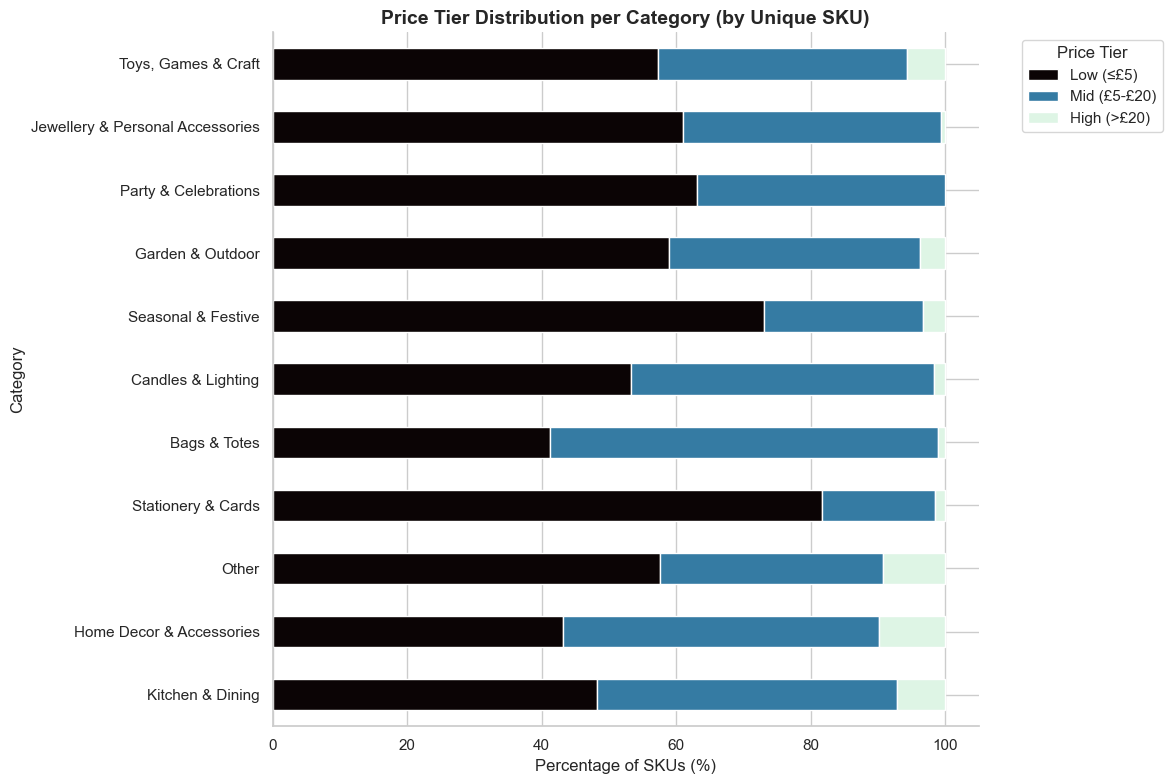

MODELLING CAVEAT - Categories with a single price tier accounting for ≥ 80% of SKUs:
 - Stationery & Cards: 81.7% in 'Low (≤£5)' tier


In [8]:
# 1. Get the maximum historical price per SKU to assign its permanent tier
sku_max_prices = df.groupby('StockCode')['Price'].max().reset_index()

# 2. Define price tiers based on fixed boundaries
# pd.cut with right=True (default) perfectly matches: <=5, 5<x<=20, and >20
bins = [-np.inf, 5.0, 20.0, np.inf]
labels = ['Low (≤£5)', 'Mid (£5-£20)', 'High (>£20)']
sku_max_prices['price_tier'] = pd.cut(sku_max_prices['Price'], bins=bins, labels=labels)

# 3. Map the assigned tier back to the main dataframe
df = df.merge(sku_max_prices[['StockCode', 'price_tier']], on='StockCode', how='left')

# 4. Calculate the proportion of unique SKUs in each tier, per category
tier_counts = df.groupby(['category', 'price_tier'], observed=False)['StockCode'].nunique().unstack(fill_value=0)
tier_props = tier_counts.div(tier_counts.sum(axis=1), axis=0) * 100

# Sort categories to match the top-to-bottom order of previous charts
cat_order = df['category'].value_counts().index
tier_props = tier_props.reindex(cat_order)

# 5. Plot the stacked bar chart
ax = tier_props.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='mako')
ax.set_title("Price Tier Distribution per Category (by Unique SKU)", fontsize=14, fontweight="bold")
ax.set_xlabel("Percentage of SKUs (%)", fontsize=12)
ax.set_ylabel("Category")

# Move legend outside the plot
ax.legend(title="Price Tier", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/06_price_tier_distribution.png')
plt.show();

# 6. Flag heavily skewed categories as a modelling caveat
skewed_cats = tier_props[tier_props.max(axis=1) >= 80]
print("MODELLING CAVEAT - Categories with a single price tier accounting for ≥ 80% of SKUs:")
for cat, row in skewed_cats.iterrows():
    dom_tier = row.idxmax()
    print(f" - {cat}: {row.max():.1f}% in '{dom_tier}' tier");

This graph tells us that:
<ol>
<li>Products under the <i>Stationery & Cards</i> and <i>Seasonal & Festive</i> are mostly (~80% and ~60%) in the low tier price category.
<li>Other categories have about 40 - 60% of their products in the Low price tier, i.e, < £5.
<li>The second biggest price tier is Medium (£5 < Price < £20).
<li>Four categories have a significant portion of their products in the High price tier (> £20):
<i><ul><li>Toys, Games & Craft
<li>Home Decor & Acessories
<li>Kitchen & Dining
<li>Other
</ul></ol></i>

## Part 4: Price vs Demand Scatterplots (Log-Log Scale)
<ol>
<li>To determine if price elasticity modelling is viable, we need to check if a baseline <i>price-demand relationship</i> exists. 
<li>We plot the <b>Median price of each SKU vs Total units sold</b> for the top 4 categories by transaction volume:
<ul>
<li>Both axes use a logarithmic scale to handle the wide spread of retail data.
<li>An overlaid linear trendline (OLS) helps us spot the general direction of the relationship.
<li>A downward slope indicates that cheaper items generally sell in higher volumes - a necessary precondition for extracting price elasticity.</ul>
</ol>

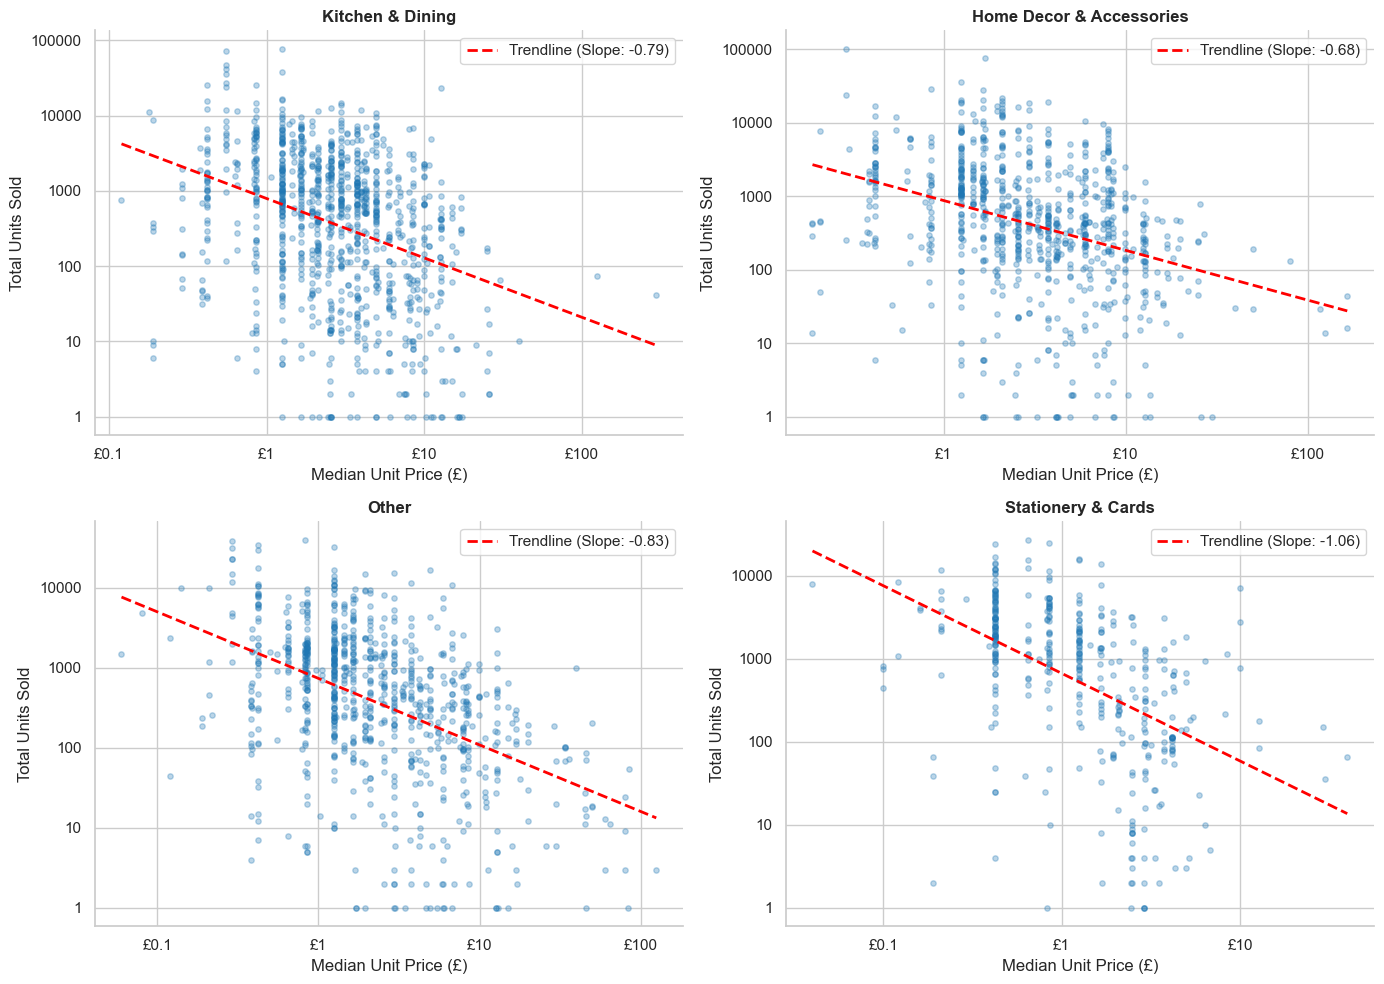

In [9]:
# 1. Identify the top 4 categories by transaction volume
top_4_cats = df['category'].value_counts().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cat in enumerate(top_4_cats):
    ax = axes[i]
    cat_df = df[df['category'] == cat]
    
    # 2. Aggregate to the SKU level
    sku_agg = cat_df.groupby('StockCode').agg(
        median_price=('Price', 'median'),
        total_qty=('Quantity', 'sum')
    ).reset_index()
    
    # 3. Filter out non-positive values (log(0) or log(negative) is undefined)
    sku_agg = sku_agg[(sku_agg['median_price'] > 0) & (sku_agg['total_qty'] > 0)]
    
    # 4. Plot the scatter points
    ax.scatter(sku_agg['median_price'], sku_agg['total_qty'], alpha=0.3, color="#1f77b4", s=15)
    
    # 5. Calculate and overlay the OLS trendline using log10 values
    log_x = np.log10(sku_agg['median_price'])
    log_y = np.log10(sku_agg['total_qty'])
    m, c = np.polyfit(log_x, log_y, 1) # m = slope, c = intercept
    
    # Generate points for the trendline
    fit_x = np.linspace(log_x.min(), log_x.max(), 100)
    fit_y = m * fit_x + c
    
    # Plot the trendline (converting log values back to original scale for plotting on log axes)
    ax.plot(10**fit_x, 10**fit_y, color='red', linestyle='--', linewidth=2, label=f'Trendline (Slope: {m:.2f})')
    
    # 6. Format axes to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Format tick labels to be readable numbers rather than scientific notation
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"£{x:g}"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))
    
    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Median Unit Price (£)')
    ax.set_ylabel('Total Units Sold')
    ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/06_price_demand_scatter.png')
plt.show();

These scatterplots confirm:
<ol>
<li><b>Price Sensitivity Exists:</b> The clear downward trendlines across all four categories prove that lower-priced items drive higher sales volumes.
<li><b>Log-Log Modelling is Valid:</b> These trends form relatively straight lines on a logarithmic scale - hence we can use a log-log OLS regression.
<li><b>Segments Behave Differently (Different Elasticities):</b> The slopes vary by category (e.g., <i>Stationery & Cards</i> is the most price-sensitive at -1.06, <i>while Home Decor</i> is less sensitive at -0.68). Therefore, we should apply a different elasticity model to each category.
</ol>

## Part 5: Sell-Through Trajectories (Peak vs. Off-Peak)
To justify building an optimisation engine, we need to prove that inventory clearance is a real problem.<br>
We do this by comparing the sell-through trajectories of the exact same products during the <b>Peak season (Q4 2010) vs Off-Peak season (Q1 2011)</b>.<br>
By mapping both timeframes to a relative 12 week window, we can overlay the cumulative sales curves. A flattening curve during the off-peak window provides the empirical evidence that products stop moving naturally after Christmas, which is the exact scenario where our markdown optimiser will intervene.

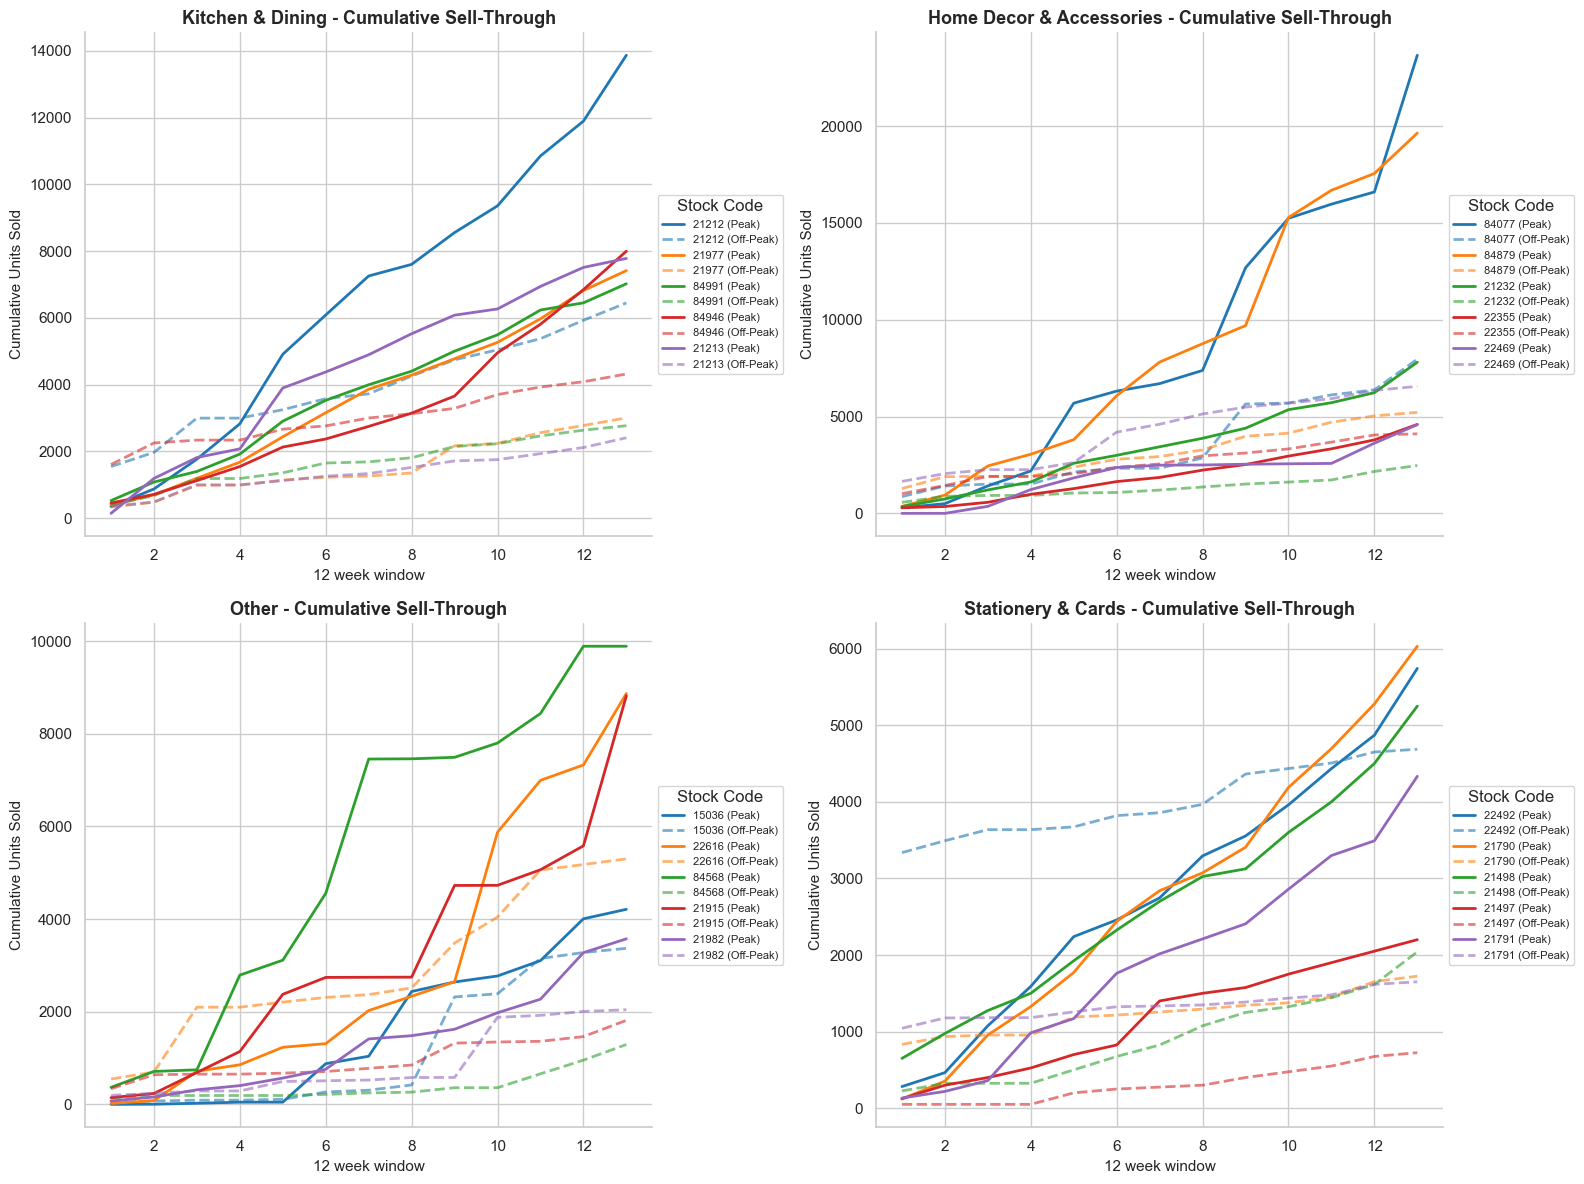

In [10]:
# 1. Create a year-week column to easily filter continuous time periods
df['year_week'] = df['year'].astype(str) + '-' + df['week'].astype(str).str.zfill(2)

# 2. Define the two 13-week time windows
# Peak: 2010 W36 to 2010 W48
peak_weeks = [f"2010-{str(w).zfill(2)}" for w in range(36, 49)]
# Off-peak: 2010 W49 to 2010 W52, then 2011 W01 to 2011 W09
offpeak_weeks = [f"2010-{str(w).zfill(2)}" for w in range(49, 53)] + \
                [f"2011-{str(w).zfill(2)}" for w in range(1, 10)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cat in enumerate(top_4_cats):
    ax = axes[i]
    cat_df = df[df['category'] == cat]
    
    # 3. Find SKUs that have sales in BOTH windows so the comparison is fair
    peak_vols = cat_df[cat_df['year_week'].isin(peak_weeks)].groupby('StockCode')['Quantity'].sum()
    offpeak_vols = cat_df[cat_df['year_week'].isin(offpeak_weeks)].groupby('StockCode')['Quantity'].sum()
    common_skus = peak_vols.index.intersection(offpeak_vols.index)
    
    # 4. Grab the top 5 highest-volume SKUs from that common pool
    top_skus = cat_df[cat_df['StockCode'].isin(common_skus)].groupby('StockCode')['Quantity'].sum().nlargest(5).index
    
    # Generate unique colours for the 5 SKUs
    colors = sns.color_palette("tab10", len(top_skus))
    
    for j, sku in enumerate(top_skus):
        sku_df = cat_df[cat_df['StockCode'] == sku]
        
        # Calculate Peak cumulative sum
        peak_data = sku_df[sku_df['year_week'].isin(peak_weeks)].groupby('year_week')['Quantity'].sum().reindex(peak_weeks, fill_value=0)
        ax.plot(range(1, len(peak_weeks) + 1), peak_data.cumsum(), color=colors[j], linestyle='-', linewidth=2, label=f"{sku} (Peak)")
        
        # Calculate Off-peak cumulative sum
        offpeak_data = sku_df[sku_df['year_week'].isin(offpeak_weeks)].groupby('year_week')['Quantity'].sum().reindex(offpeak_weeks, fill_value=0)
        ax.plot(range(1, len(offpeak_weeks) + 1), offpeak_data.cumsum(), color=colors[j], linestyle='--', linewidth=2, alpha=0.6, label=f"{sku} (Off-Peak)")
        
    ax.set_title(f"{cat} - Cumulative Sell-Through", fontsize=13, fontweight='bold')
    ax.set_xlabel("12 week window", fontsize=11)
    ax.set_ylabel("Cumulative Units Sold", fontsize=11)
    
    # Place legend outside the plot so it doesn't cover the lines
    ax.legend(title="Stock Code",fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/06_sell_through_trajectories.png')
plt.show();

What this plot tells us:
<ol>
<li><b>Demand reduces heavily off-peak:</b> Products stop selling as much after the peak period ends.
<li><b>Markdowns are justified:</b> Because off-peak trajectories are relatively flatter, remaining stock will not clear at full price and we can build a markdown optimisation model to boost sales post peak periods.
</ol>

## Part 6: Conclusion & Next Steps<br>
<ol>
<li><b>Demand flatlines off-peak:</b> Products stop selling as much after the peak period ends. Because off-peak trajectories are relatively flatter, remaining stock will not clear at full price. Markdowns are empirically justified.
<li><b>Price Coherence:</b> Categories exhibit different price regimes with slight but signifacnt variance (IQR) within them. This validates the decision to segment the data rather than using a global model.
<li><b>Elasticity Signal:</b> Log-log scatterplots show a clear downward trend across major categories, confirming that baseline price sensitivity exists and log-log elasticity modeling is viable.
</ol>